In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv(r"/content/train_FD001.csv")

In [ ]:
cols = ['id', 'num_of_cycles','op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

df.columns = cols

In [ ]:
df.head()

In [ ]:
max_cycles = df.groupby('id')['num_of_cycles'].max().reset_index()
max_cycles.columns = ['id', 'max_cycles']

In [ ]:
df = df.merge(max_cycles, on='id', how='left')

In [ ]:
df.head()

In [ ]:
df["RUL"]= df["max_cycles"] - df["num_of_cycles"]
df["RUL"] = df["RUL"].clip(upper=125)

In [ ]:
df.head()

In [ ]:
def classify_rul(rul):
    if rul > 100:
        return "Healthy"
    elif rul > 50:
        return "Warning"
    else:
        return "Critical"

df["class"] = df["RUL"].apply(classify_rul)

# 1-Data Understanding

In [ ]:
# Show a random sample of the data
print("Random sample of data:\n")
df.sample(15)

In [ ]:
# Show the size of the data (rows, columns)
print("Size of data:", df.shape)

In [ ]:
# Show info about columns, data types, and non-null values
print("\nData info:")
df.info()

In [ ]:
# Show all column names
print("\nColumn names:")
print(df.columns)

In [ ]:
# Show basic statistics (mean, min, max, etc.) for numeric columns
print("\nData description:")
df.describe()

In [ ]:
# Show how many unique values each column has
print("\nUnique values in each column:")
print(df.nunique())

In [ ]:
# Show how many times each id appears
print("\nValue counts of 'id':")
df["id"].value_counts()

In [ ]:
# Show how many times each value appears in num_of_cycles
print("\nValue counts of 'num_of_cycles':")
print(df["num_of_cycles"].value_counts())

In [ ]:
# Show how many times each value appears in op_setting_1
print("\nValue counts of 'op_setting_1':")
print(df["op_setting_1"].value_counts())

In [ ]:
# Show how many times each value appears in op_setting_2
print("\nValue counts of 'op_setting_2':")
print(df["op_setting_2"].value_counts())

In [ ]:
# Show how many times each value appears in op_setting_3
print("\nValue counts of 'op_setting_3':")
print(df["op_setting_3"].value_counts())

# 2-Data cleaning

In [ ]:
no_variance = [col for col in df.columns if df[col].nunique() == 1]
print("\nSensors with no variance:", no_variance)

In [ ]:
df.head()

# 3-EDA

### 1-Univariate Analysis

In [ ]:
numerical_cols = df.select_dtypes(include="number").columns

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.tight_layout()

plt.show()


In [ ]:
numerical_cols = df.select_dtypes(include="number").columns

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()


In [ ]:
sns.countplot(x=df['class'])
plt.title("Distribution of Target")
plt.show()

### 2-Bivariate Analysis

In [ ]:
numerical_df= df.drop("class",axis=1)
numerical_df.corr()

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(numerical_df.corr(), annot=True)
plt.tight_layout()
plt.show()

In [ ]:
numerical_df.corr()['RUL'].sort_values()

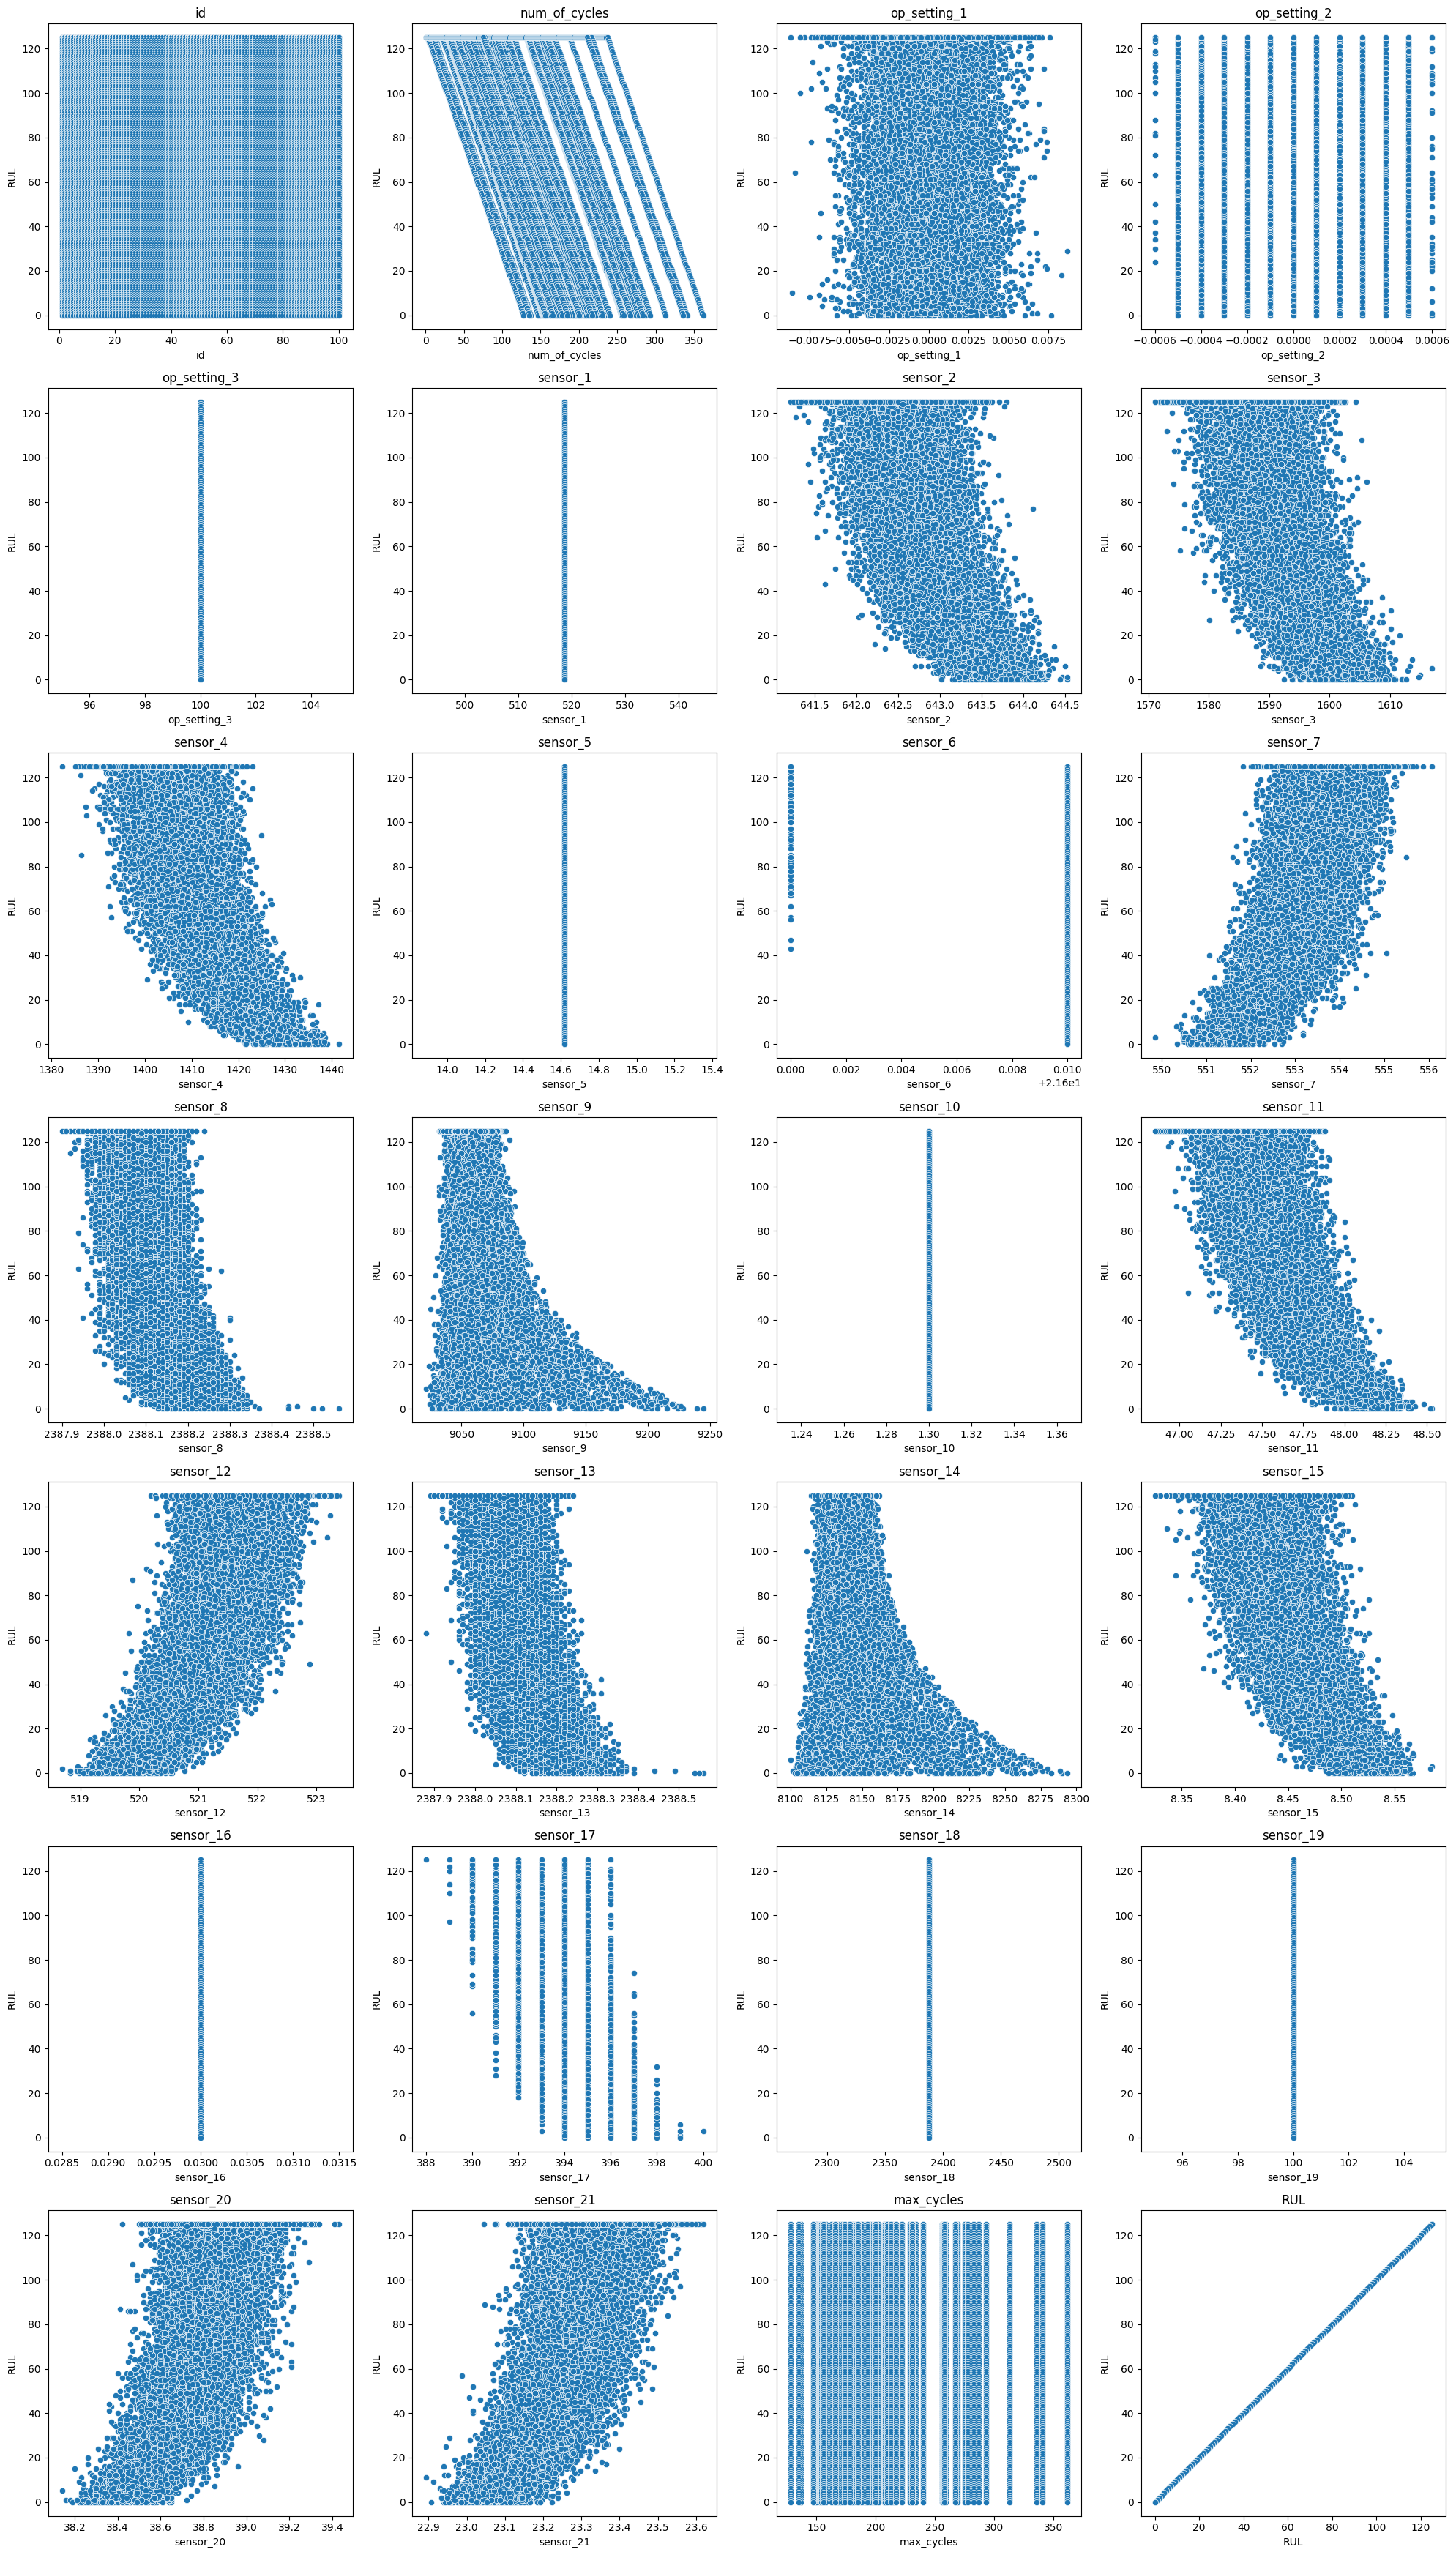

In [ ]:
numerical_cols = df.select_dtypes(include="number").columns

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(data=df, x=col, y="RUL")
    plt.title(col)
    plt.tight_layout()

plt.show()


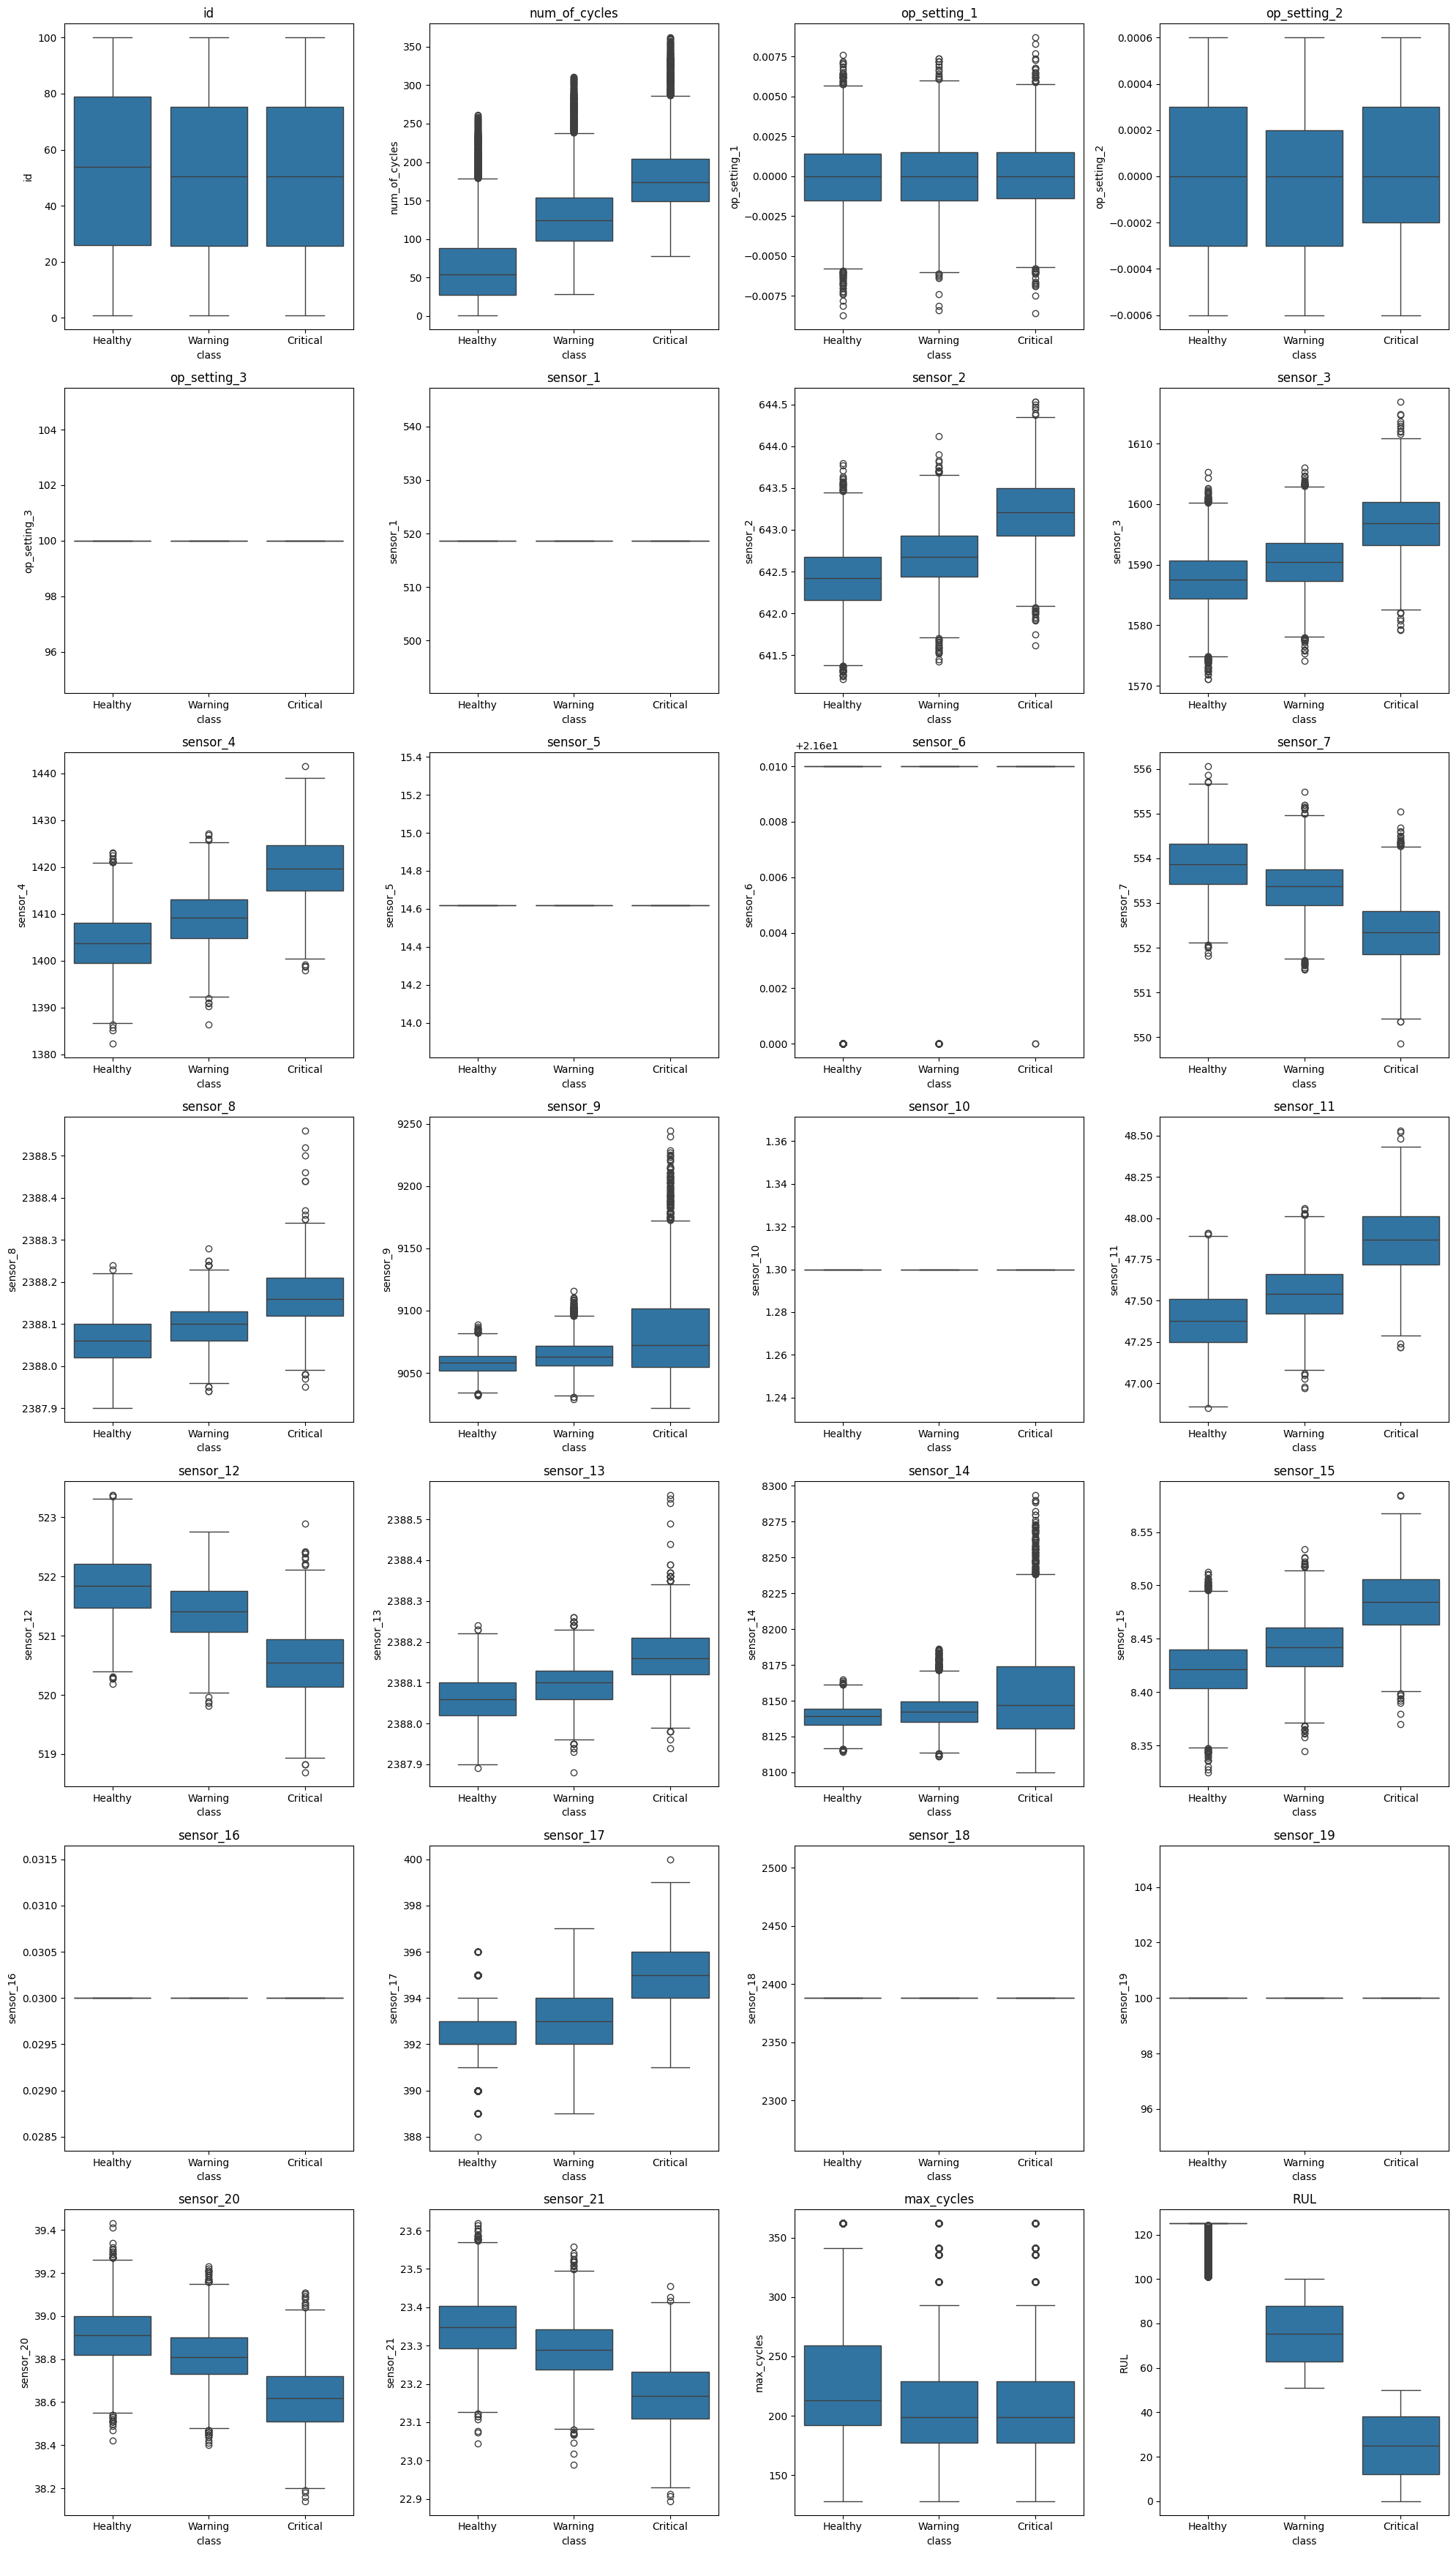

In [ ]:
numerical_cols = df.select_dtypes(include="number").columns

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, x="class", y=col)
    plt.title(col)
    plt.tight_layout()

plt.show()


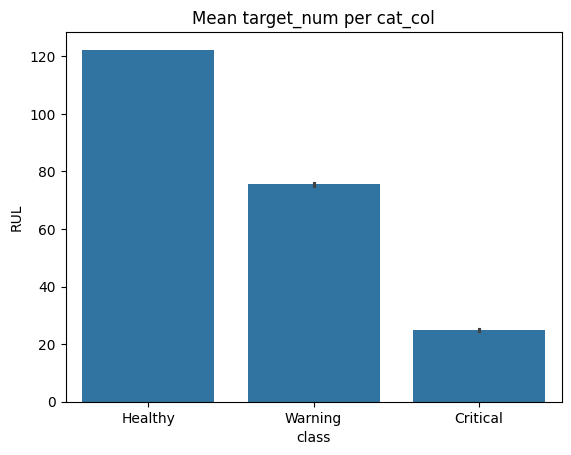

In [ ]:
sns.barplot(data=df, x='class', y='RUL', estimator='mean')
plt.title('Mean target_num per cat_col')
plt.show()

In [ ]:
df.groupby('class').agg(["min","max","mean","median","std"])

id                                   num_of_cycles                   \
         min  max       mean median        std           min  max        mean   
class                                                                           
Critical   1  100  50.500000   50.5  28.868900            78  362  181.310000   
Healthy    1  100  52.476828   54.0  29.535211             1  261   63.255745   
Warning    1  100  50.500000   50.5  28.868957            28  311  130.810000   

                            ... max_cycles                                     \
         median        std  ...        min  max        mean median        std   
class                       ...                                                 
Critical  174.0  48.407644  ...        128  362  206.310000  199.0  46.114975   
Healthy    54.0  46.910487  ...        128  362  226.502944  213.0  51.621053   
Warning   124.0  48.320709  ...        128  362  206.310000  199.0  46.115065   

          RUL                                     
          min  max        mean median        std  
class                                             
Critical    0   50   25.000000   25.0  14.721045  
Healthy   101  125  122.150997  125.0   6.198431  
Warning    51  100   75.500000   75.5  14.432313  

[3 rows x 140 columns]

### 3-Multivariate Analysis

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numerical_cols=numerical_cols = df.select_dtypes("number").columns.drop("RUL")
X = df[numerical_cols]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)


          feature           VIF
0              id  1.062817e+00
1   num_of_cycles  3.150255e+00
2    op_setting_1  1.002206e+00
3    op_setting_2  1.001576e+00
4    op_setting_3  0.000000e+00
5        sensor_1  0.000000e+00
6        sensor_2  2.644731e+00
7        sensor_3  2.294603e+00
8        sensor_4  4.611686e+00
9        sensor_5  2.083202e-08
10       sensor_6  1.032055e+00
11       sensor_7  4.355217e+00
12       sensor_8  4.717091e+00
13       sensor_9  1.790209e+01
14      sensor_10  1.863252e-08
15      sensor_11  6.060420e+00
16      sensor_12  5.314307e+00
17      sensor_13  4.704555e+00
18      sensor_14  1.728711e+01
19      sensor_15  3.310546e+00
20      sensor_16  1.639438e-07
21      sensor_17  2.566000e+00
22      sensor_18  0.000000e+00
23      sensor_19  0.000000e+00
24      sensor_20  3.072215e+00
25      sensor_21  3.122213e+00
26     max_cycles  1.597859e+00


In [ ]:
# Identify numeric columns
num_cols = df.select_dtypes(include=np.number).columns
print("Numeric columns:")
print(num_cols)


Numeric columns:
Index(['id', 'num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycles', 'RUL'],
      dtype='object')


In [ ]:

# Z-score method
z_scores = np.abs(stats.zscore(df[num_cols]))
outliers_z = (z_scores > 3).sum(axis=0)
print("Outliers detected by Z-score method per column:")
print(outliers_z)


Outliers detected by Z-score method per column:
[  0  94  53   0   0   0  31  47  36   0 406  34 107 521   0  23  34  83
 496  33   0  81   0   0  43  34   0   0]


In [ ]:

# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
print("Outliers detected by IQR method per column:")
print(outliers_iqr)


Outliers detected by IQR method per column:
id                  0
num_of_cycles     104
op_setting_1      105
op_setting_2        0
op_setting_3        0
sensor_1            0
sensor_2          139
sensor_3          165
sensor_4          119
sensor_5            0
sensor_6          406
sensor_7          110
sensor_8          320
sensor_9         1686
sensor_10           0
sensor_11         167
sensor_12         146
sensor_13         161
sensor_14        1543
sensor_15         120
sensor_16           0
sensor_17          81
sensor_18           0
sensor_19           0
sensor_20         117
sensor_21         136
max_cycles       1039
RUL                 0
dtype: int64


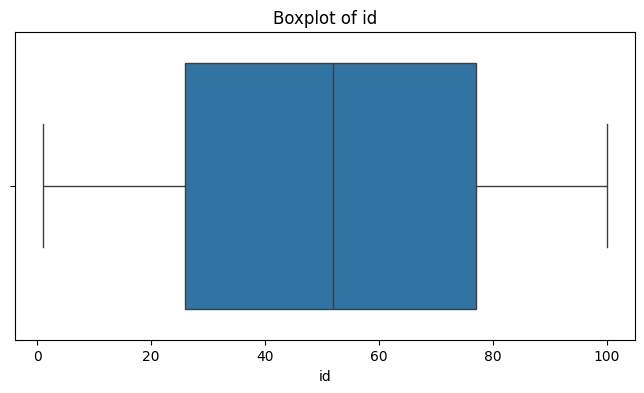

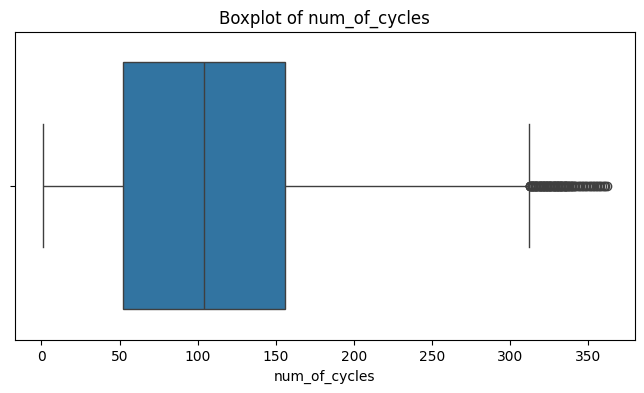

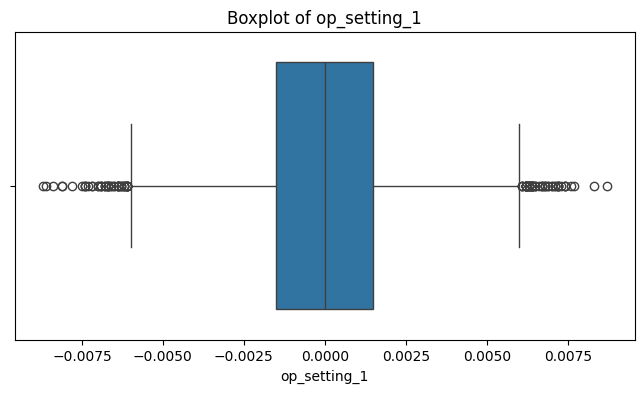

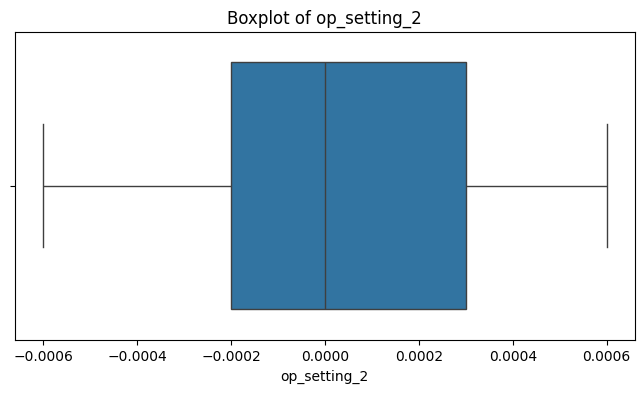

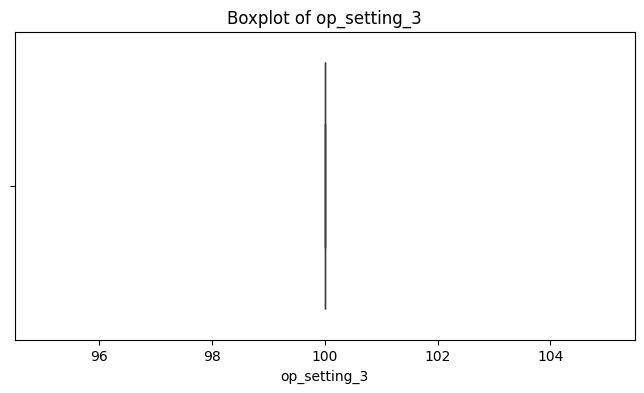

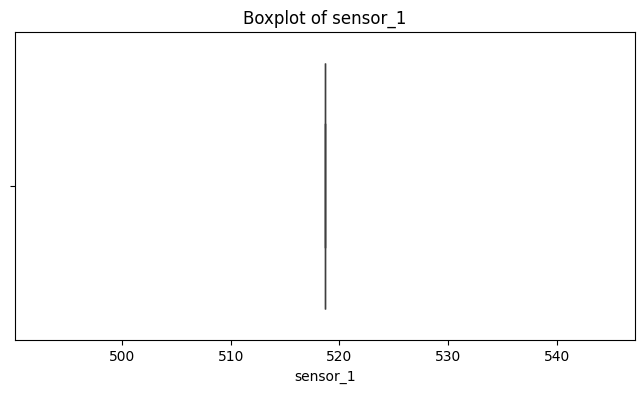

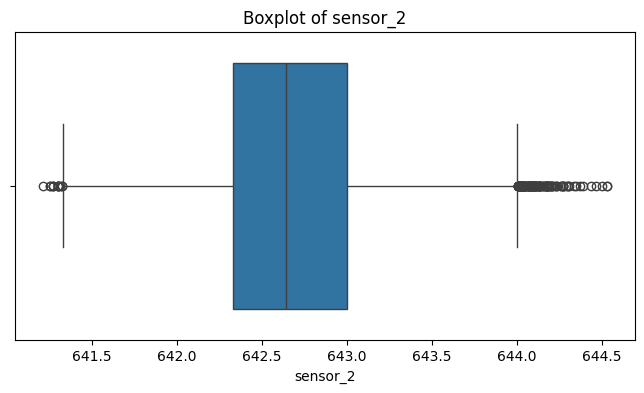

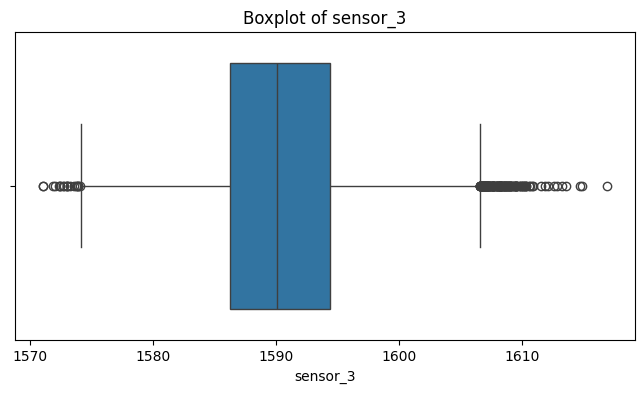

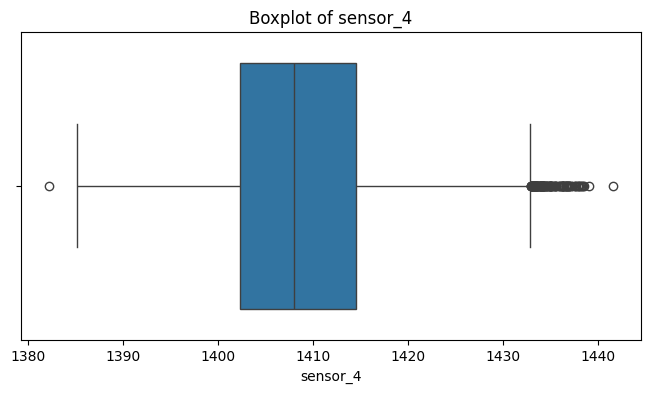

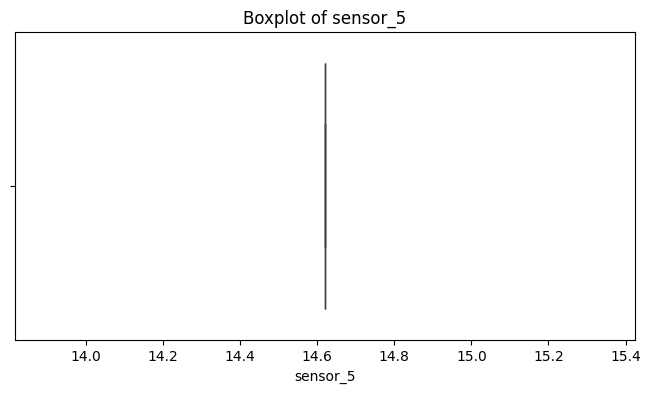

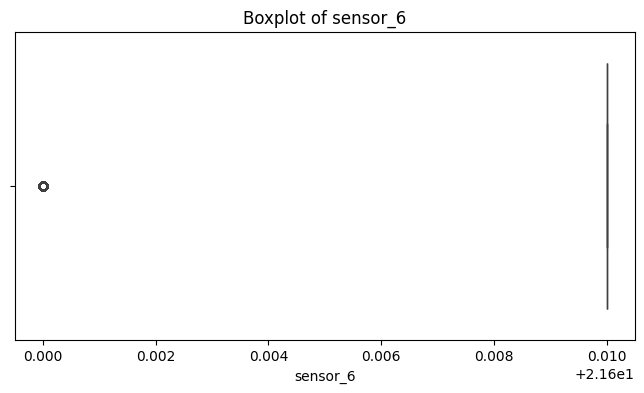

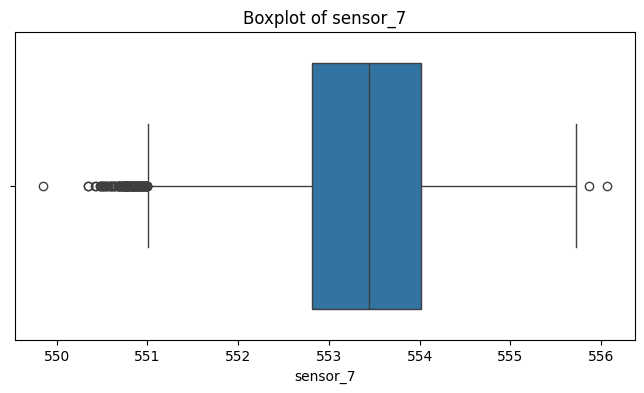

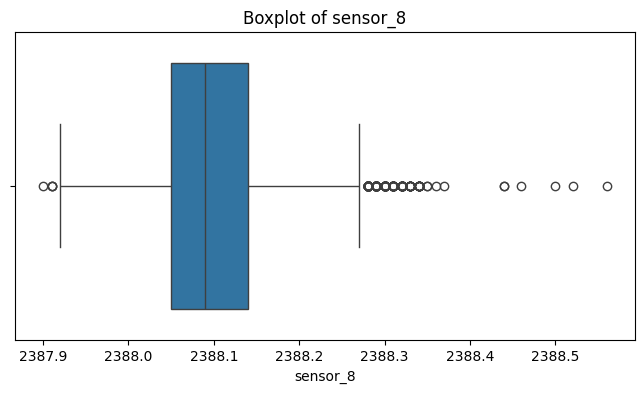

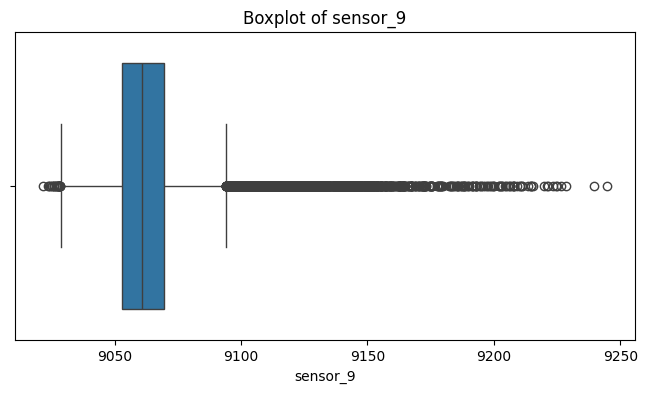

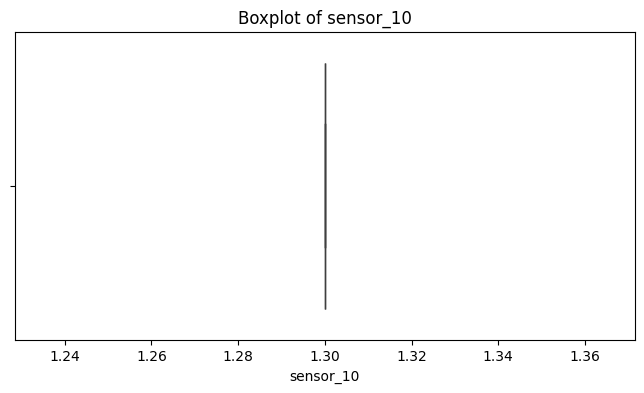

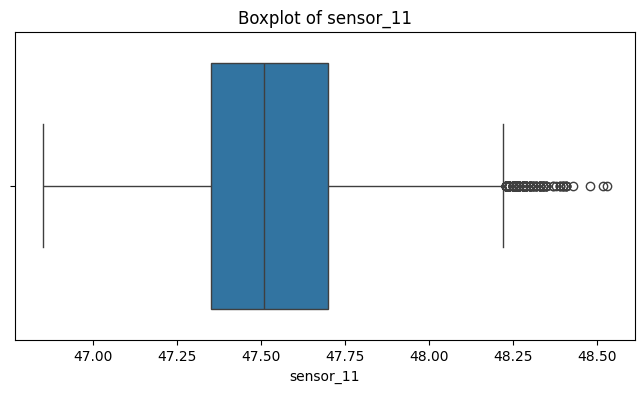

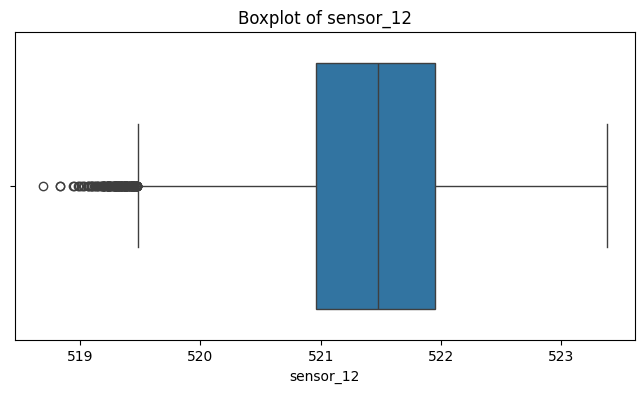

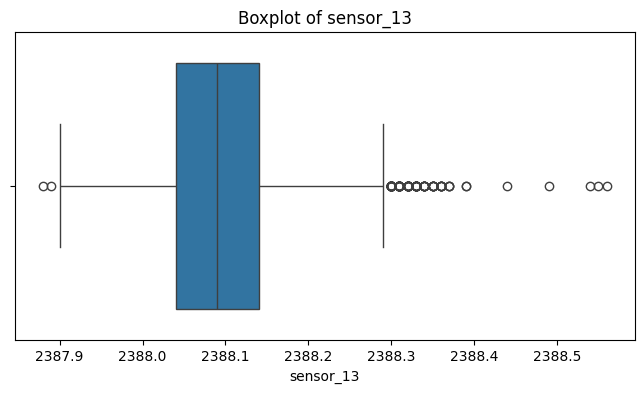

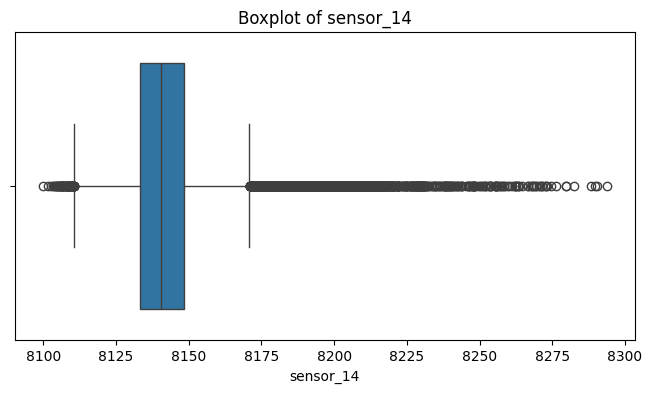

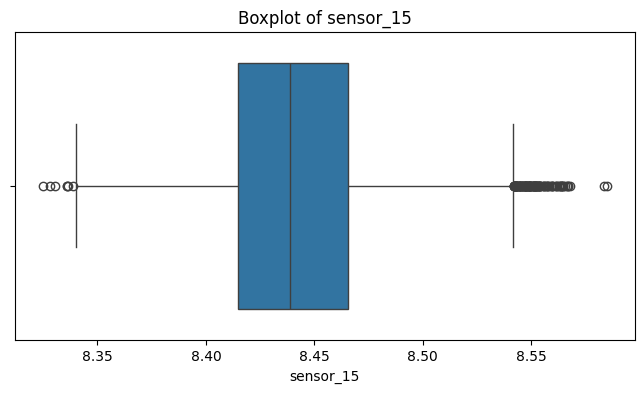

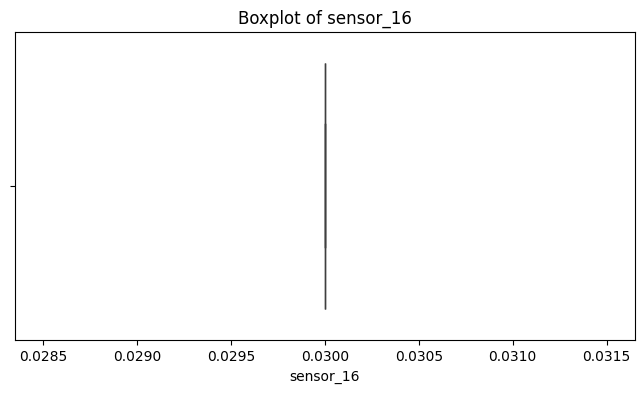

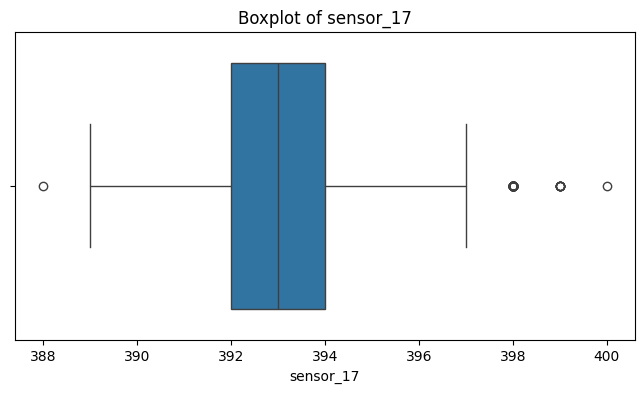

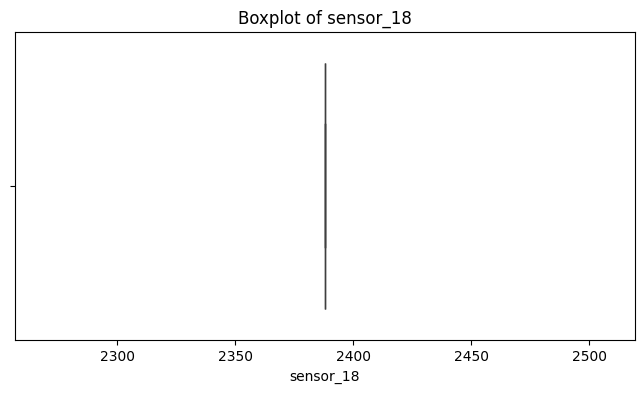

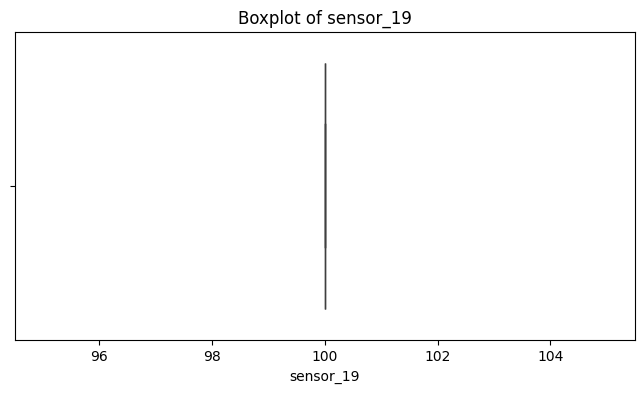

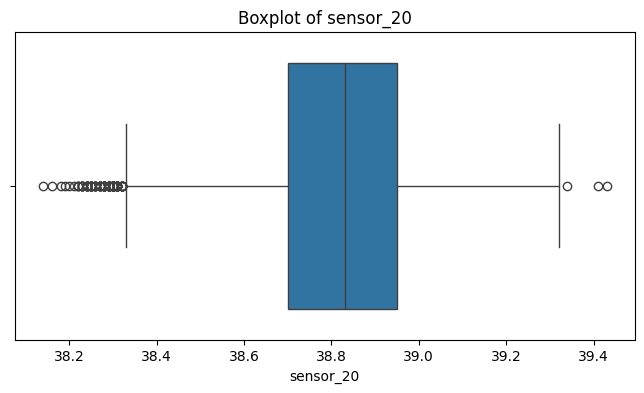

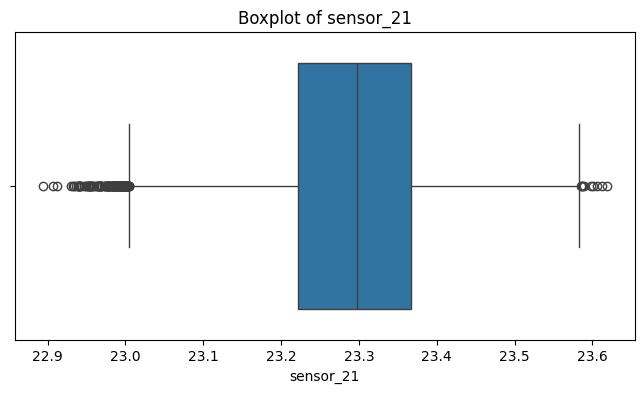

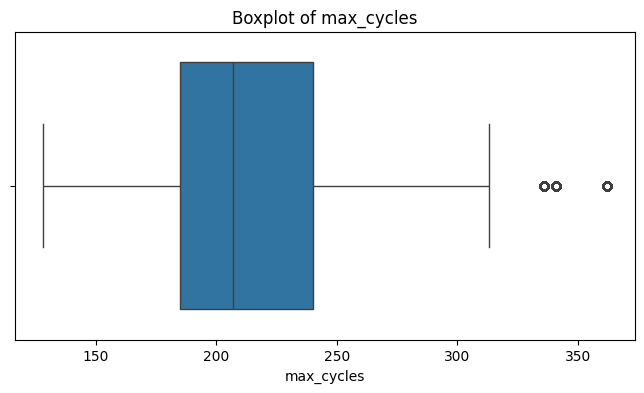

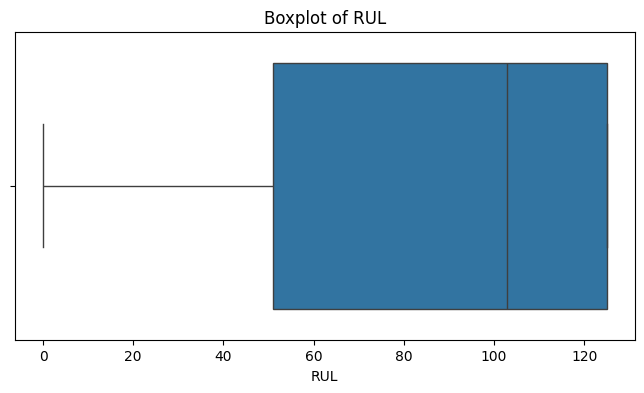

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [ ]:
# Check for negative values
for col in num_cols:
    if (df[col] < 0).any():
        print(f"Negative values found in column {col}")


Negative values found in column op_setting_1
Negative values found in column op_setting_2


In [ ]:
# Rare categories for numeric columns with few unique values
for col in num_cols:
    if df[col].nunique() < 20:
        value_counts = df[col].value_counts(normalize=True)
        rare = value_counts[value_counts < 0.01]
        if not rare.empty:
            print(f"Rare categories in {col}:")
            print(rare)


Rare categories in op_setting_2:
op_setting_2
 0.0006    0.003442
-0.0006    0.001648
Name: proportion, dtype: float64
Rare categories in sensor_17:
sensor_17
398    0.003490
389    0.001454
399    0.000339
388    0.000048
400    0.000048
Name: proportion, dtype: float64


In [ ]:
#!pip install ydata-profiling

In [ ]:
# Optional: Automated EDA report using ydata_profiling
'''
import ydata_profiling
profile = ydata_profiling.ProfileReport(df)
profile.to_widgets()
profile.to_file("eda_report.html")'''




'\nimport ydata_profiling\nprofile = ydata_profiling.ProfileReport(df)\nprofile.to_widgets()\nprofile.to_file("eda_report.html")'

In [ ]:

# Correlation of numeric features with RUL
correlations = df[num_cols].corr()["RUL"].sort_values(ascending=False)
print("Correlation of numeric features with RUL:")
print(correlations)


Correlation of numeric features with RUL:
RUL              1.000000
sensor_12        0.748872
sensor_7         0.733008
sensor_21        0.707320
sensor_20        0.704611
max_cycles       0.188717
id               0.031625
op_setting_1    -0.005542
op_setting_2    -0.007030
sensor_6        -0.108297
sensor_14       -0.369749
sensor_9        -0.462130
sensor_13       -0.624017
sensor_8        -0.624562
sensor_3        -0.655038
sensor_2        -0.678444
sensor_17       -0.680819
sensor_15       -0.720853
num_of_cycles   -0.746929
sensor_4        -0.757147
sensor_11       -0.775235
op_setting_3          NaN
sensor_1              NaN
sensor_5              NaN
sensor_10             NaN
sensor_16             NaN
sensor_18             NaN
sensor_19             NaN
Name: RUL, dtype: float64


#  4-Data Preprocessing

### 1-Feature Cleaning

In [ ]:
# Drop columns with no variance only
no_variance = [col for col in df.columns if df[col].nunique() == 1]
df.drop(no_variance, axis=1, inplace=True)

# Remove 'max_cycles'
if 'max_cycles' in df.columns:
    df.drop(['max_cycles'], axis=1, inplace=True)

###  2- Outlier Handling (Capping"without RUL")

In [ ]:
# Select numeric columns except RUL
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('RUL')

# Apply IQR capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


### 3- Encoding Target (Classification)

In [ ]:
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Critical': np.int64(0), 'Healthy': np.int64(1), 'Warning': np.int64(2)}


###4-Rolling Features

In [ ]:
# Define sensors with high correlation to RUL
important_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15', 'sensor_20', 'sensor_21']

# Calculate rolling mean and std for a window of 10 cycles
for col in important_sensors:
    df[f'{col}_roll_mean'] = df.groupby('id')[col].transform(lambda x: x.rolling(window=10).mean())
    df[f'{col}_roll_std'] = df.groupby('id')[col].transform(lambda x: x.rolling(window=10).std())

# Drop rows with NaN values created by rolling window
df.dropna(inplace=True)

if 'id' in df.columns:
    df.drop(['id'], axis=1, inplace=True)

print("Feature engineering complete. New shape:", df.shape)

Feature engineering complete. New shape: (19730, 39)


## 4-REGRESSION PIPELINE (Predict RUL)

###4.1-Regression dataset

In [ ]:
df_reg = df.copy()

X_reg = df_reg.drop(['RUL', 'class', 'class_encoded'], axis=1)
y_reg = df_reg['RUL']


In [ ]:
features_list = list(df_reg.drop(['RUL', 'class', 'class_encoded'], axis=1).columns)

print("Number of features:", len(features_list))
print("Features order:", features_list)

import joblib
joblib.dump(features_list, 'features_list.pkl')

Number of features: 36
Features order: ['num_of_cycles', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean', 'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std', 'sensor_7_roll_mean', 'sensor_7_roll_std', 'sensor_11_roll_mean', 'sensor_11_roll_std', 'sensor_12_roll_mean', 'sensor_12_roll_std', 'sensor_15_roll_mean', 'sensor_15_roll_std', 'sensor_20_roll_mean', 'sensor_20_roll_std', 'sensor_21_roll_mean', 'sensor_21_roll_std']


['features_list.pkl']

### 4.2-Scaling (Regression)

In [ ]:
imputer = SimpleImputer(strategy='median')
X_reg = imputer.fit_transform(X_reg)

scaler = StandardScaler()
X_reg = scaler.fit_transform(X_reg)


### 4.3-Train-test split (Regression)

In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


##5-CLASSIFICATION PIPELINE (Health State)

###5.1-Classification dataset

In [ ]:
df_cls = df.copy()

X_cls = df_cls.drop(['RUL', 'class', 'class_encoded'], axis=1)
y_cls = df_cls['class_encoded']


### 5.2-Handle imbalance (SMOTE)

In [ ]:
print("Before SMOTE:", Counter(y_cls))

smote = SMOTE(random_state=42)
X_cls, y_cls = smote.fit_resample(X_cls, y_cls)

print("After SMOTE:", Counter(y_cls))


Before SMOTE: Counter({1: 9630, 0: 5100, 2: 5000})
After SMOTE: Counter({1: 9630, 2: 9630, 0: 9630})


### 5.3-Scaling (Classification)

In [ ]:
X_cls = imputer.fit_transform(X_cls)
X_cls = scaler.fit_transform(X_cls)


###5.4-Train-test split (Classification)

In [ ]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)


#5-Modeling(XGBoost)

In [ ]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix

###1- Regression Modeling (Predicting RUL)

In [ ]:
print("--- Training Regression Model (XGBoost) ---")
# Using more estimators and a smaller learning rate for better convergence
reg_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

--- Training Regression Model (XGBoost) ---


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

###1.2-Evaluation

Regression MAE: 9.19
Regression R2 Score: 0.90


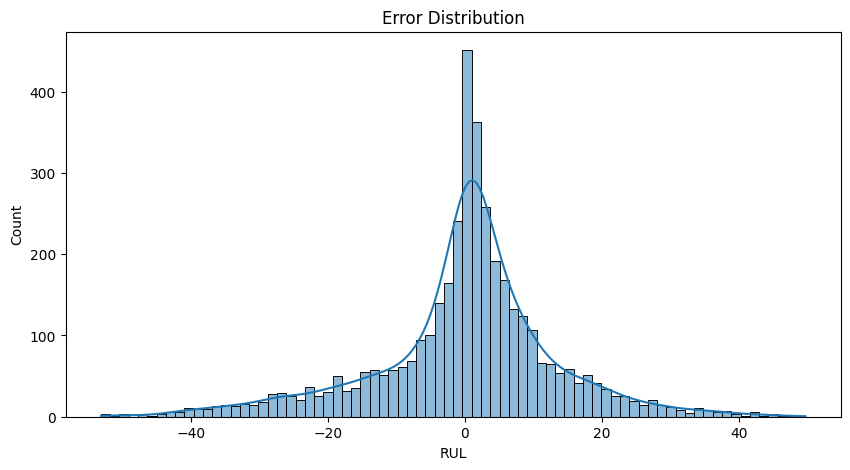

In [ ]:
# Predict and evaluate
y_pred_reg = reg_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Regression MAE: {mae:.2f}")
print(f"Regression R2 Score: {r2:.2f}")

# Plotting Residuals
plt.figure(figsize=(10,5))
sns.histplot(y_test_reg - y_pred_reg, kde=True)
plt.title('Error Distribution')
plt.show()

###2- Classification Modeling (Predicting Health State)

In [ ]:
print("--- Training Classification Model (XGBoost) ---")
cls_model = XGBClassifier(n_estimators=100, random_state=42)
cls_model.fit(X_train_cls, y_train_cls)

--- Training Classification Model (XGBoost) ---


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

###2.2-Evaluation

In [ ]:
y_pred_cls = cls_model.predict(X_test_cls)
print("Classification Report:")
print(classification_report(y_test_cls, y_pred_cls, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

    Critical       0.98      0.94      0.96      1926
     Healthy       0.93      0.93      0.93      1926
     Warning       0.89      0.92      0.91      1926

    accuracy                           0.93      5778
   macro avg       0.93      0.93      0.93      5778
weighted avg       0.93      0.93      0.93      5778



#6-Feature Importance

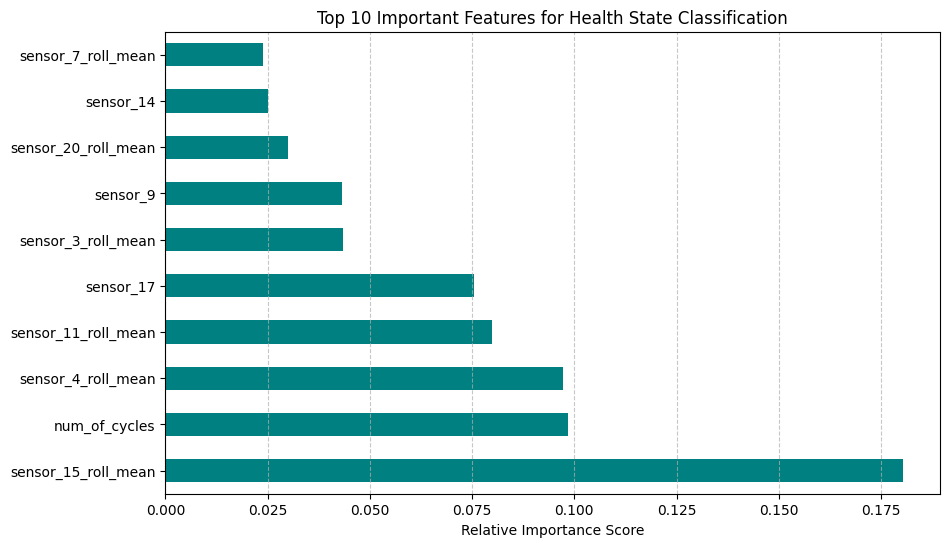

In [ ]:
# Create a series for feature importances
feat_importances = pd.Series(cls_model.feature_importances_, index=df_cls.drop(['RUL', 'class', 'class_encoded'], axis=1).columns)

# Plot top 10 features
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Important Features for Health State Classification')
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

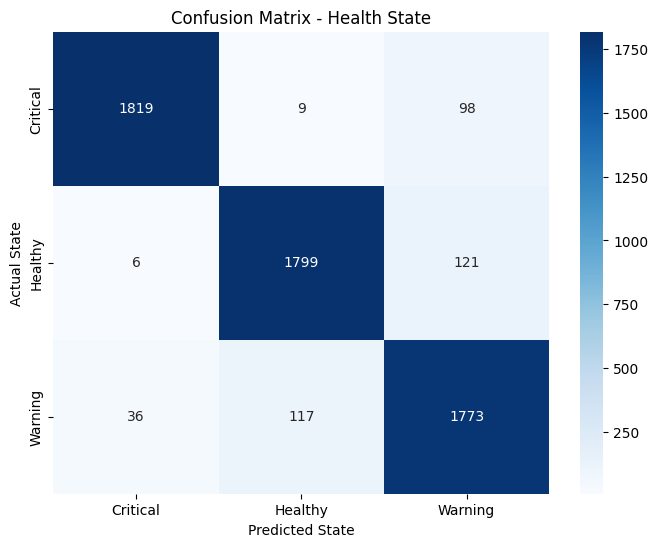

In [ ]:
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Health State')
plt.ylabel('Actual State')
plt.xlabel('Predicted State')
plt.show()

#7- Saving Models

In [ ]:
import joblib

# Saving models, scaler and label encoder
joblib.dump(reg_model, 'reg_model.pkl')
joblib.dump(cls_model, 'cls_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("All models and scalers are saved. Download them to your computer.")

All models and scalers are saved. Download them to your computer.


#Project Summary
####Dataset: C-MAPSS FD001

Approach: Implemented XGBoost for both RUL prediction (Regression) and Health State classification

Key Improvement: Adding Rolling features (Mean & Std) and RUL Clipping significantly improved the MAE from ~25 to 9.19

Classification Performance: Achieved 93% Accuracy using SMOTE to handle class imbalance

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import io

# 1. Function to smart-read the file
def smart_read_nasa(filename):
    # Try reading with spaces first (NASA default)
    df = pd.read_csv(filename, header=None, sep='\s+', engine='python')

    # If it results in only 1 column, try reading with commas
    if df.shape[1] == 1:
        df = pd.read_csv(filename, header=None, sep=',')

    # If still 1 column, there might be an issue with the file content
    if df.shape[1] == 1:
        raise ValueError("The file seems to have only 1 column. Please check if it's a valid NASA dataset.")

    return df

# --- Main Processing ---
try:
    print("Reading file...")
    # Use the smart reader
    df = smart_read_nasa('test_FD001.csv')

    # Keep only the first 26 columns
    df = df.iloc[:, :26]

    # Adding Column Names
    columns = ['unit_number', 'num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
    df.columns = columns
    print(f"✅ Successfully identified {df.shape[1]} columns.")

    # 2. Calculating Rolling Features (The 36 features logic)
    rolling_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15', 'sensor_20', 'sensor_21']
    for s in rolling_sensors:
        df[f'{s}_roll_mean'] = df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
        df[f'{s}_roll_std'] = df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))

    # 3. Adding extra columns to match your favorite format
    df['max_cycles'] = df.groupby('unit_number')['num_of_cycles'].transform('max')
    df['RUL'] = 120 # Placeholder
    df['class'] = 'Healthy' # Placeholder

    # 4. Save and Download
    output_name = 'processed_FD001_test.csv'
    df.to_csv(output_name, index=False)
    print(f"✅ Success! File '{output_name}' is ready.")
    files.download(output_name)

except Exception as e:
    print(f"❌ Error: {e}")

Reading file...
✅ Successfully identified 26 columns.
✅ Success! File 'processed_FD001_test.csv' is ready.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>